# Лабораторная работа №4, Вариант 11

## Решение задачи многомерной регрессии

### Цели и задачи работы
**Цель лабораторной работы:** изучение принципов решения задачи многомерной регрессии с использованием методов машинного обучения.

**Основные задачи:**
- Изучение инструментария Python для реализации алгоритмов многомерной регрессии
- Освоение метода линейной регрессии
- Изучение методов оценки корректности модели многомерной линейной регрессии

### Датасет – x11.csv

Набор данных для изучения структуры арендной платы за пастбища с учетом разнообразия трав. Включает данные по различным округам Миннесоты.

**Атрибуты:**
- **Number** – индекс
- **RentPerArableAcre (A1)** – арендная плата за акр пахотной земли (в долларах)
- **MilkCowsPerSquareMile (A2)** – количество дойных коров на квадратную милю
- **DifferenceBetweenPastureAndArable (A3)** – разница между пастбищами и пахотными землями
- **RentalPrice (B)** – цена аренды за акр для данного сорта травы (целевая переменная)

## Выполнение работы

### 1. Импорт библиотек и загрузка данных

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

# Загрузка данных
df = pd.read_csv('x11.csv')
df.head()

,Number,RentPerArableAcre,MilkCowsPerSquareMile,DifferenceBetweenPastureAndArable,RentalPrice
0,1,15.50,17.25,0.24,18.38
1,2,22.29,18.51,0.20,20.00
2,3,12.36,11.13,0.12,11.50
3,4,31.84,5.54,0.12,25.00
4,5,83.90,5.44,0.04,62.50


### Получим информацию о датасете

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Number                             67 non-null     object 
 1   RentPerArableAcre                  67 non-null     float64
 2   MilkCowsPerSquareMile              67 non-null     float64
 3   DifferenceBetweenPastureAndArable  67 non-null     float64
 4   RentalPrice                        67 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.7+ KB


### Проверяем наличие пропущенных значений и выбросов

In [39]:
print(df.isnull().sum())

Number                               0
RentPerArableAcre                    0
MilkCowsPerSquareMile                0
DifferenceBetweenPastureAndArable    0
RentalPrice                          0
dtype: int64


In [53]:
y = df['RentalPrice']
X = df.drop(['RentalPrice', 'Number'], axis=1)

# убедимся, что данные в нужном нам формате
type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [41]:
# посмотрим на признаки
X.head()

,RentPerArableAcre,MilkCowsPerSquareMile,DifferenceBetweenPastureAndArable
0,15.50,17.25,0.24
1,22.29,18.51,0.20
2,12.36,11.13,0.12
3,31.84,5.54,0.12
4,83.90,5.44,0.04


### Разделяем данные на обучающую и тестовую выборку
75% данных используется для обучения и 25% — для тестирования.

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.25, random_state=0)

### Применяем операцию нормализации для численной устойчивости

In [43]:
# импортируем класс для стандартизации данных
from sklearn.preprocessing import StandardScaler
# и создания модели линейной регрессии
from sklearn.linear_model import LinearRegression

# создадим объект класса StandardScaler
scaler = StandardScaler()
scaler
# StandardScaler()

StandardScaler()

### Масштабируем признаки обучающей выборки

In [44]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# убедился, что объект scaler запомнил значения среднего и СКО для каждого признака
scaler.mean_, scaler.scale_

(array([42.9348, 19.8708,  0.172 ]),
 array([20.97950116, 13.66395753,  0.13536617]))

### Обучаем модель линейной регрессии

In [45]:
# применим масштабированные данные для обучения модели линейной регрессии
model = LinearRegression().fit(X_train_scaled, y_train)
model
# LinearRegression()

LinearRegression()

### Делаем прогноз на основе данных тестирование

In [46]:
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)
y_pred[:5]

array([66.76314826, 74.87201744, 65.54199129, 55.87264734, 39.88362666])

In [47]:
from sklearn.metrics import root_mean_squared_error
print('Root Mean Squared Error (RMSE):', root_mean_squared_error(y_test, y_pred))

Root Mean Squared Error (RMSE): 11.881851435318735


In [48]:
# посмотрим на еще одну метрику - коэффициент детерминации R2
from sklearn.metrics import r2_score
print('R2:', np.round(r2_score(y_test, y_pred), 2))

R2: 0.81


In [49]:
# оценим R-квадрат (метрика (score) по умолчанию для класса LinearRegression)
model.score(X_test_scaled, y_test)

0.8145349993633413

### Итоговое уравнение
#### y = w_1 * x_1 + w_2 * x_2 + … + w_n * x_n + w_0

In [50]:
# Коэффициенты
print ('Coefficients: ', model.coef_)

Coefficients:  [17.56351994  5.55249288 -0.53862624]


In [51]:
# Свободный член
print ('Intercept: ', model.intercept_)

Intercept:  40.6086


In [57]:
from sklearn.preprocessing import LabelEncoder
labelencoder_o = LabelEncoder()
df[''] = labelencoder_o.fit_transform(df[''])
df

### Оценка влияния признаков на целевую переменную

In [59]:
# Создаем датафрейм только с числовыми столбцами (исключаем 'Number')
numeric_df = df.select_dtypes(include=[np.number])

# Матрица корреляций
correlation_matrix = numeric_df.corr()
print("Матрица корреляций:")
correlation_matrix

Матрица корреляций:


,RentPerArableAcre,MilkCowsPerSquareMile,DifferenceBetweenPastureAndArable,RentalPrice
RentPerArableAcre,1.000000,0.045504,-0.497893,0.885082
MilkCowsPerSquareMile,0.045504,1.000000,0.522598,0.303392
DifferenceBetweenPastureAndArable,-0.497893,0.522598,1.000000,-0.330177
RentalPrice,0.885082,0.303392,-0.330177,1.000000


### Визуализация результатов регрессии

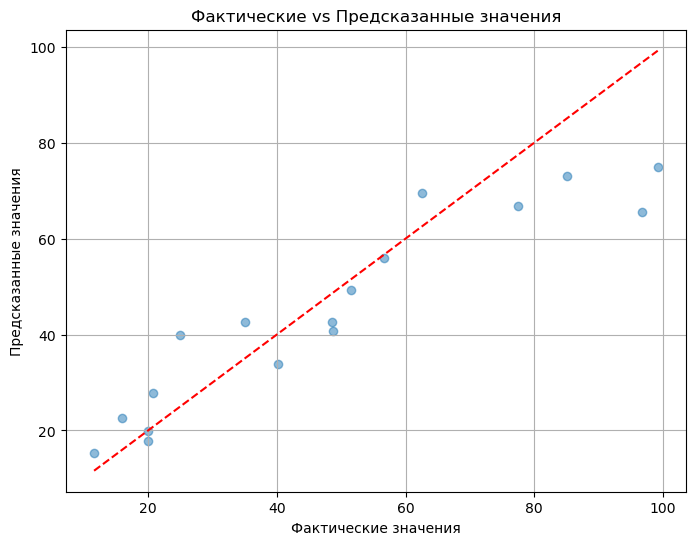

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические vs Предсказанные значения")
plt.grid()
plt.show()

### Остатки регрессии (Residuals Plot)
Остаток — это разница между фактическим и предсказанным значением (y_true - y_pred).
Этот график помогает проверить важное предположение линейной регрессии: что остатки случайны и не имеют паттернов.

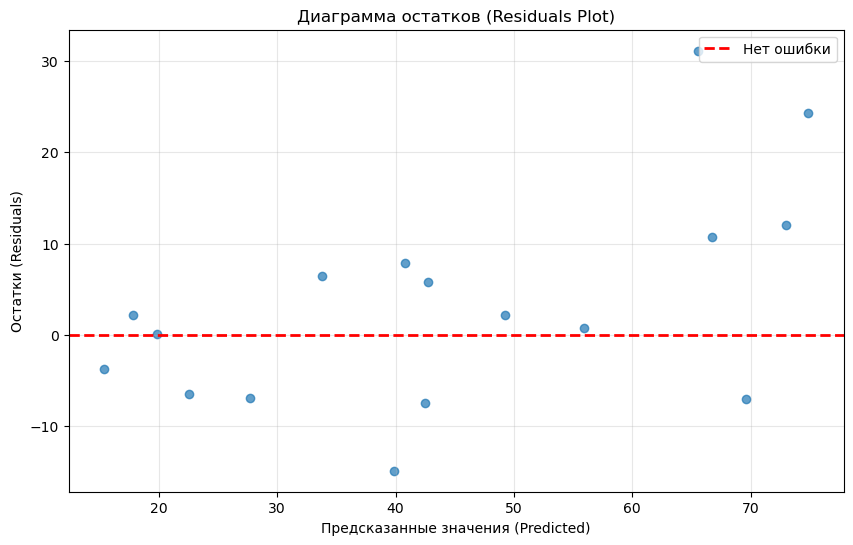

In [55]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Нет ошибки')
plt.xlabel('Предсказанные значения (Predicted)')
plt.ylabel('Остатки (Residuals)')
plt.title('Диаграмма остатков (Residuals Plot)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Результаты:

- **Хорошо**: Остатки беспорядочно разбросаны вокруг горизонтальной красной линии (нуля), нет никаких явных дуг, форм или конусов.

- **Плохо**: Остатки образуют форму "воронки" (гетероскедастичность) или кривую линию (нелинейность), что говорит о неадекватности модели.